## 
Gradient Boosting Classifier
- xgboost
- lightgbm

In [1]:
# Imports
import xgboost as xgb
import lightgbm as lgb
import pandas as pd
import cupy as cp
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score, brier_score_loss,  confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Parameters
RANDOM_STATE = 42
TEST_SIZE = 0.2

## Data Preprocessing

In [3]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df = pd.read_csv('../datasets/basic_all_dataset.csv')

df_sample = df.sample(frac=0.25, random_state=42)


In [4]:
# Splitting the data
from sklearn.model_selection import train_test_split

X_gpu = cp.asarray(df.drop('winner', axis=1))
y_gpu = cp.asarray(df['winner'])

X_cpu = df.drop('winner', axis=1)
y_cpu = df['winner']

X_train_gpu, X_test_gpu, y_train_gpu, y_test_gpu = train_test_split(X_gpu , y_gpu, test_size=TEST_SIZE, random_state=RANDOM_STATE)
X_train_cpu, X_test_cpu, y_train_cpu, y_test_cpu = train_test_split(X_cpu, y_cpu, test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_sample_gpu = cp.asarray(df_sample.drop('winner', axis=1))
y_sample_gpu = cp.asarray(df_sample['winner'])

X_sample_cpu = df_sample.drop('winner', axis=1)
y_sample_cpu = df_sample['winner']

X_sample_train_gpu, X_sample_test_gpu, y_sample_train_gpu, y_sample_test_gpu = train_test_split(X_sample_gpu , y_sample_gpu, test_size=TEST_SIZE, random_state=RANDOM_STATE)
X_sample_train_cpu, X_sample_test_cpu, y_sample_train_cpu, y_sample_test_cpu = train_test_split(X_sample_cpu, y_sample_cpu, test_size=TEST_SIZE, random_state=RANDOM_STATE)

assert X_train_cpu.shape[0] == y_train_cpu.shape[0]
assert X_test_cpu.shape[0] == y_test_cpu.shape[0]

assert X_sample_train_cpu.shape[0] == y_sample_train_cpu.shape[0]
assert X_sample_test_cpu.shape[0] == y_sample_test_cpu.shape[0]

X_train_cpu.shape, X_test_cpu.shape, y_train_cpu.shape, y_test_cpu.shape, X_sample_train_cpu.shape, X_sample_test_cpu.shape, y_sample_train_cpu.shape, y_sample_test_cpu.shape

((5269809, 11),
 (1317453, 11),
 (5269809,),
 (1317453,),
 (1317452, 11),
 (329364, 11),
 (1317452,),
 (329364,))

## Training XGBoost

In [5]:

xgb_model_classifier = xgb.XGBClassifier(eval_metric='auc', random_state=RANDOM_STATE, device="cuda")
xgb_model_classifier.fit(X_train_gpu, y_train_gpu)
pred_probs = xgb_model_classifier.predict_proba(X_test_gpu)[:, 1]  # Probability of class 1

brier = brier_score_loss(y_test_cpu, pred_probs)

print(f"Brier Score (Classification): {brier:.4f}")

Brier Score (Classification): 0.1697


In [6]:
xgb_model_regressor = xgb.XGBRegressor(eval_metric='mae', random_state=RANDOM_STATE, device="cuda")
xgb_model_regressor.fit(X_train_gpu, y_train_gpu)
pred = xgb_model_regressor.predict(X_test_gpu)

pred_clamped = np.clip(pred, 0, 1)

brier = brier_score_loss(y_test_cpu, pred_clamped)
print(f"Brier Score (Regression): {brier}")

Brier Score (Regression): 0.1696892401387859


## Training LightGBM

In [7]:
lgb_model_classifier = lgb.LGBMClassifier(random_state=RANDOM_STATE, force_col_wise=True, device='gpu')
lgb_model_classifier.fit(X_train_cpu, y_train_cpu)
pred_probs = lgb_model_classifier.predict_proba(X_test_cpu)[:, 1] # Probability of class 1

brier = brier_score_loss(y_test_cpu, pred_probs)
print(f"Brier Score (Classification): {brier:.4f}")

[LightGBM] [Info] Number of positive: 2584844, number of negative: 2684965
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 5269809, number of used features: 11
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3060 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (60.31 MB) transferred to GPU in 0.040965 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.490501 -> initscore=-0.038003
[LightGBM] [Info] Start training from score -0.038003
Brier Score (Classification): 0.1701


In [8]:
lgb_model_regressor = lgb.LGBMRegressor(random_state=RANDOM_STATE, force_col_wise=True, device='gpu')
lgb_model_regressor.fit(X_train_cpu, y_train_cpu)
pred = lgb_model_regressor.predict(X_test_cpu)

pred_clamped = np.clip(pred, 0, 1)

brier = brier_score_loss(y_test_cpu, pred_clamped)
print(f"Brier Score (Regression): {brier:.4f}")

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 5269809, number of used features: 11
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 3060 Ti, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 9 dense feature groups (60.31 MB) transferred to GPU in 0.040703 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 0.490501
Brier Score (Regression): 0.1700


## Grid Search

In [9]:
import numpy as np
import itertools
from tqdm import tqdm
import time


def grid_search(param_grid, build_model, fit, predict, condition, best_score_start, X_train, y_train, X_test, y_test):
    best_score = best_score_start
    best_params = {}

    param_combinations = itertools.product(*param_grid.values())
    len_data =np.prod([len(v) for v in param_grid.values()])
    print(f"Starting grid search over {len_data} parameter combinations...\n")


    start_time = time.time()

    for i, combination in enumerate(tqdm(param_combinations, desc="Grid Search Progress", total=len_data)):
        params = dict(zip(param_grid.keys(), combination))
        try: 
            model = build_model(params)
    
            fit(model, X_train, y_train)
    
            score = predict(model, X_test, y_test)
        except Exception as e:
            print(f'Warning: model, fit or score is crashing {e}')
            continue

        if condition(score, best_score):
            best_score = score
            best_params = params

    end_time = time.time()
    time_taken = end_time - start_time
    print(f"\nGrid Search Completed in {time_taken:.2f} seconds.")

    print(f"\nBest Parameters: {best_params}")
    print(f"Best brier Score: {best_score:.4f}")
    return best_params

## Hyperparameter Tuning with GridSearchCV for XGBoost

In [10]:
params_XG_classifier = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

params_XG_regressor = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

def condition(score, best_score):
    return score < best_score

def fit(model, X_train, y_train):
    model.fit(X_train, y_train)

def predict_classifier(model, X_test, y_test):
    pred = model.predict_proba(X_test)[:,1]
    return brier_score_loss(y_test, pred)

def predict_regressor(model, X_test, y_test):
    pred = model.predict(X_test)
    return brier_score_loss(y_test, np.clip(pred, 0, 1))

#best_params_classifier = grid_search(params_XG_classifier,
#                lambda params: xgb.XGBClassifier(**params, eval_metric="auc", n_jobs=-1, random_state=RANDOM_STATE, device="cuda"),
#                fit,
#                predict_classifier,  
#                    condition,
#                np.inf,
#                X_sample_train_gpu, y_sample_train_gpu, X_sample_test_gpu, y_sample_test_cpu)

print("""
Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [4:34:55<00:00,  1.19it/s]  


Grid Search Completed in 16495.20 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.5, 'reg_lambda': 1.5}
Best brier Score: 0.1692
""")

best_params_classifier = {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.5, 'reg_lambda': 1.5}

#best_params_regressor = grid_search(params_XG_regressor,
#                lambda params: xgb.XGBRegressor(**params, eval_metric="mae", n_jobs=-1, random_state=RANDOM_STATE, device="cuda"),
#                fit,
#                predict_regressor,  
#                condition,
#                np.inf,
#                X_sample_train_gpu, y_sample_train_gpu, X_sample_test_gpu, y_sample_test_cpu)

print("""
Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [4:23:27<00:00,  1.25it/s]  


Grid Search Completed in 15807.19 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 1.5}
Best brier Score: 0.1692
""")

best_params_regressor = {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 1.5}

xgb_model_classifier = xgb.XGBClassifier(**best_params_classifier, eval_metric='auc', random_state=RANDOM_STATE, device="cuda")
xgb_model_classifier.fit(X_train_gpu, y_train_gpu)
print("XGBoost Classifier", predict_classifier(xgb_model_classifier, X_test_gpu, y_test_cpu))

xgb_model_regressor = xgb.XGBRegressor(**best_params_regressor, eval_metric='mae', random_state=RANDOM_STATE, device="cuda")
xgb_model_regressor.fit(X_train_gpu, y_train_gpu)
print("XGBoost Regressor", predict_regressor(xgb_model_regressor, X_test_gpu, y_test_cpu))


Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [4:34:55<00:00,  1.19it/s]  


Grid Search Completed in 16495.20 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0.5, 'reg_lambda': 1.5}
Best brier Score: 0.1692


Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [4:23:27<00:00,  1.25it/s]  


Grid Search Completed in 15807.19 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 1.5}
Best brier Score: 0.1692

XGBoost Classifier 0.1690565869031339
XGBoost Regressor 0.16931586351737773


## Hyperparameter Tuning with GridSearchCV for LightGBM

In [14]:
params_LGB_classifier = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

params_LGB_regressor = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [1, 3, 5],
    'num_leaves': [12, 25, 50],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

#best_params_classifier = grid_search(params_LGB_classifier,
#                lambda params: lgb.LGBMClassifier(**params, n_jobs=-1, random_state=RANDOM_STATE, force_col_wise=True, verbose=-1, device="gpu"),
#                fit,
#                predict_classifier,  
#                condition,
#                np.inf,
#                X_sample_train_cpu, y_sample_train_cpu, X_sample_test_cpu, y_sample_test_cpu)

print("""
Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [21:23:45<00:00,  3.91s/it]


Grid Search Completed in 77025.09 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 2}
Best brier Score: 0.1692
""")

best_params_classifier = {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 7, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 2}

#best_params_regressor = grid_search(params_XG_regressor,
#                lambda params: lgb.LGBMRegressor(**params, n_jobs=-1, random_state=RANDOM_STATE, force_col_wise=True, verbose=-1, device="gpu"),
#                fit,
#                predict_regressor,  
#                condition,
#                np.inf,
#                X_sample_train_cpu, y_sample_train_cpu, X_sample_test_cpu, y_sample_test_cpu)


print("""

Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [21:23:45<00:00,  3.91s/it]


Grid Search Completed in 75423.53 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 2}
Best brier Score: 0.1692
""")

best_params_regressor = {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 2}

lgb_model_classifier = lgb.LGBMClassifier(**best_params_classifier, random_state=RANDOM_STATE, force_col_wise=True)
lgb_model_classifier.fit(X_train_cpu, y_train_cpu)
print("LGBM Classifier", predict_classifier(lgb_model_classifier, X_test_cpu, y_test_cpu))

lgb_model_regressor = lgb.LGBMRegressor(**best_params_regressor, random_state=RANDOM_STATE, force_col_wise=True)
lgb_model_regressor.fit(X_train_cpu, y_train_cpu)
print("LGBM Regressor", predict_regressor(lgb_model_regressor, X_test_cpu, y_test_cpu))


Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [21:23:45<00:00,  3.91s/it]


Grid Search Completed in 77025.09 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 2}
Best brier Score: 0.1692



Starting grid search over 19683 parameter combinations...

Grid Search Progress: 100%|██████████| 19683/19683 [21:23:45<00:00,  3.91s/it]


Grid Search Completed in 75423.53 seconds.

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.2, 'max_depth': 7, 'num_leaves': 100, 'min_child_samples': 10, 'subsample': 0.9, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 2}
Best brier Score: 0.1692

[LightGBM] [Info] Number of positive: 2584844, number of negative: 2684965
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 5269809, number 

## Model Evaluation

In [15]:
from tabulate import tabulate

def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    
    y_pred_probs = model.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_pred_probs)
    
    return accuracy, precision, recall, f1, auc, brier

def evaluate_regressor(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    y_pred_clamped = np.clip(y_pred, 0, 1)
    brier = brier_score_loss(y_test, y_pred_clamped)
    
    return mae, mse, r2, brier

xgb_classifier_results = evaluate_classifier(xgb_model_classifier, X_test_gpu, y_test_cpu)
lgb_classifier_results = evaluate_classifier(lgb_model_classifier, X_test_cpu, y_test_cpu)

xgb_regressor_results = evaluate_regressor(xgb_model_regressor, X_test_gpu, y_test_cpu)
lgb_regressor_results = evaluate_regressor(lgb_model_regressor, X_test_cpu, y_test_cpu)


# Prepare results in a structured format
headers = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "Brier Score"]
classifier_results = [
    ["XGBoost Classifier"] + list(xgb_classifier_results),
    ["LightGBM Classifier"] + list(lgb_classifier_results)
]

headers_regressor = ["Model", "MAE", "MSE", "R²", "Brier Score"]
regressor_results = [
    ["XGBoost Regressor"] + list(xgb_regressor_results),
    ["LightGBM Regressor"] + list(lgb_regressor_results)
]

# Print classification results as a table
print("Classification Metrics:")
print(tabulate(classifier_results, headers=headers, tablefmt="github"))

# Print regression results as a table
print("\nRegression Metrics:")
print(tabulate(regressor_results, headers=headers_regressor, tablefmt="github"))

Classification Metrics:
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   AUC-ROC |   Brier Score |
|---------------------|------------|-------------|----------|------------|-----------|---------------|
| XGBoost Classifier  |   0.731741 |    0.749082 | 0.681187 |   0.713523 |  0.730791 |      0.169057 |
| LightGBM Classifier |   0.731187 |    0.747569 | 0.682259 |   0.713423 |  0.730268 |      0.169451 |

Regression Metrics:
| Model              |      MAE |      MSE |       R² |   Brier Score |
|--------------------|----------|----------|----------|---------------|
| XGBoost Regressor  | 0.339338 | 0.169318 | 0.322481 |      0.169316 |
| LightGBM Regressor | 0.338886 | 0.169069 | 0.323478 |      0.169064 |


## Confusion Matrix & ROC Curve

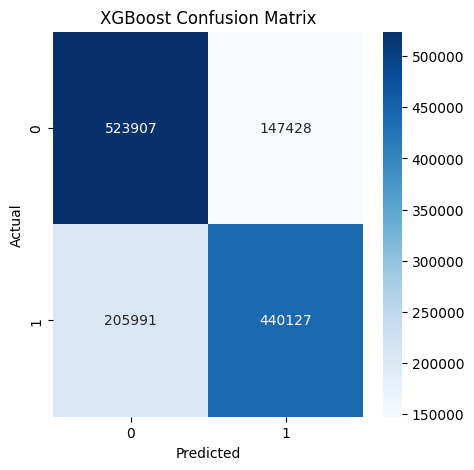

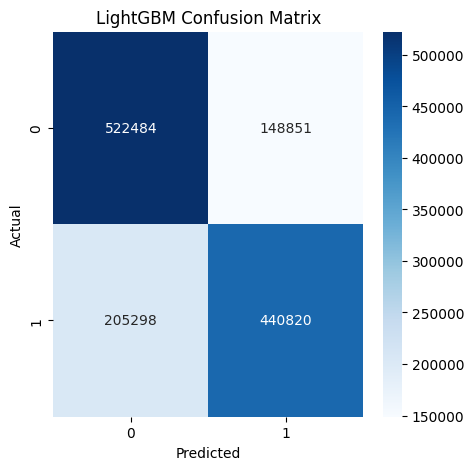

In [16]:
def plot_confusion_matrix(model, X_test, y_test, title):
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(xgb_model_classifier, X_test_gpu, y_test_cpu, 'XGBoost Confusion Matrix')
plot_confusion_matrix(lgb_model_classifier, X_test_cpu, y_test_cpu, 'LightGBM Confusion Matrix')

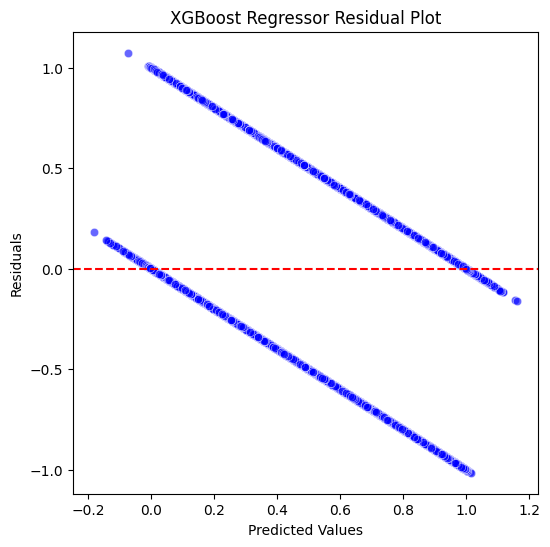

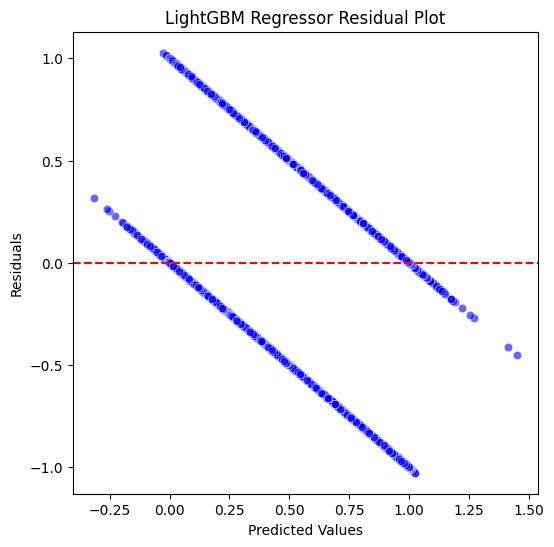

In [17]:
def plot_residuals(y_test, y_pred, title):
    residuals = y_test - y_pred
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_pred, y=residuals, color='blue', alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(title)
    plt.show()

plot_residuals(y_test_cpu, xgb_model_regressor.predict(X_test_gpu), 'XGBoost Regressor Residual Plot')
plot_residuals(y_test_cpu, lgb_model_regressor.predict(X_test_cpu), 'LightGBM Regressor Residual Plot')

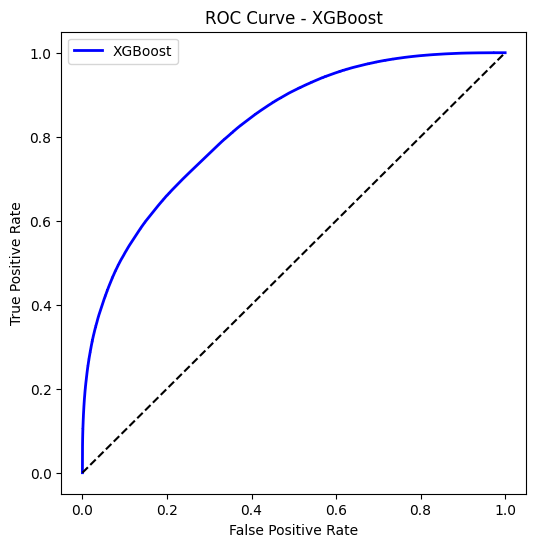

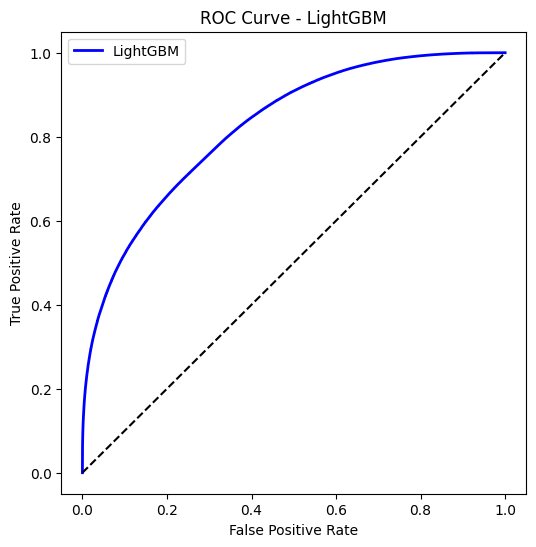

In [18]:
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_test, y_test, label):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label, linewidth=2, color='blue')
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend()
    plt.show()

plot_roc_curve(xgb_model_classifier, X_test_gpu, y_test_cpu, 'XGBoost')
plot_roc_curve(lgb_model_classifier, X_test_cpu, y_test_cpu, 'LightGBM')

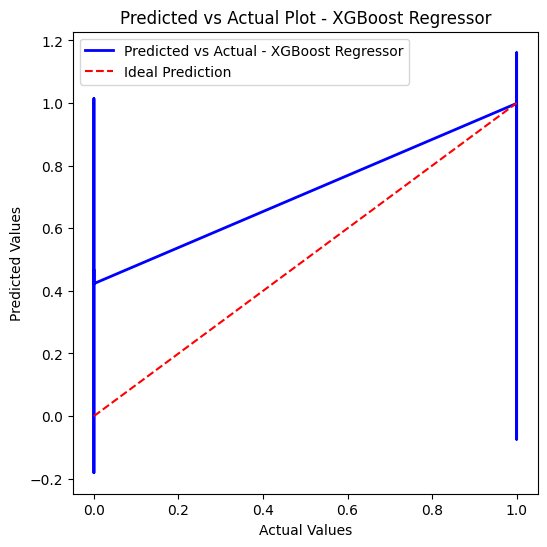

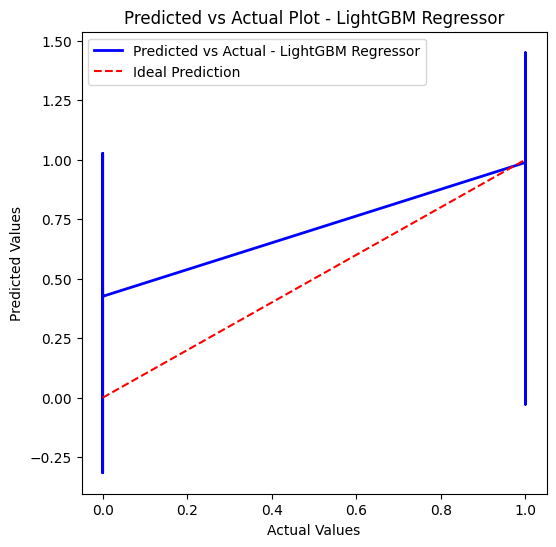

In [19]:
def plot_predicted_vs_actual_regressor(y_test, y_pred, label):
    y_test = np.array(y_test) 
    sorted_indices = np.argsort(y_test)
    sorted_y_test = y_test[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    
    plt.figure(figsize=(6, 6))
    plt.plot(sorted_y_test, sorted_y_pred, label=f'Predicted vs Actual - {label}', color='blue', linewidth=2)
    plt.plot([min(sorted_y_test), max(sorted_y_test)], [min(sorted_y_test), max(sorted_y_test)], 'r--', label="Ideal Prediction")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Predicted vs Actual Plot - {label}')
    plt.legend()
    plt.show()

plot_predicted_vs_actual_regressor(y_test_cpu, xgb_model_regressor.predict(X_test_gpu), 'XGBoost Regressor')
plot_predicted_vs_actual_regressor(y_test_cpu, lgb_model_regressor.predict(X_test_cpu), 'LightGBM Regressor')

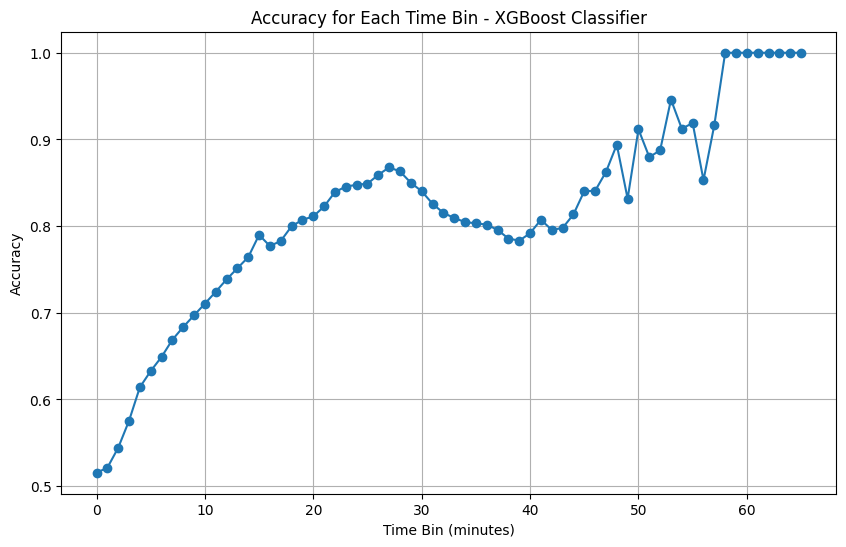

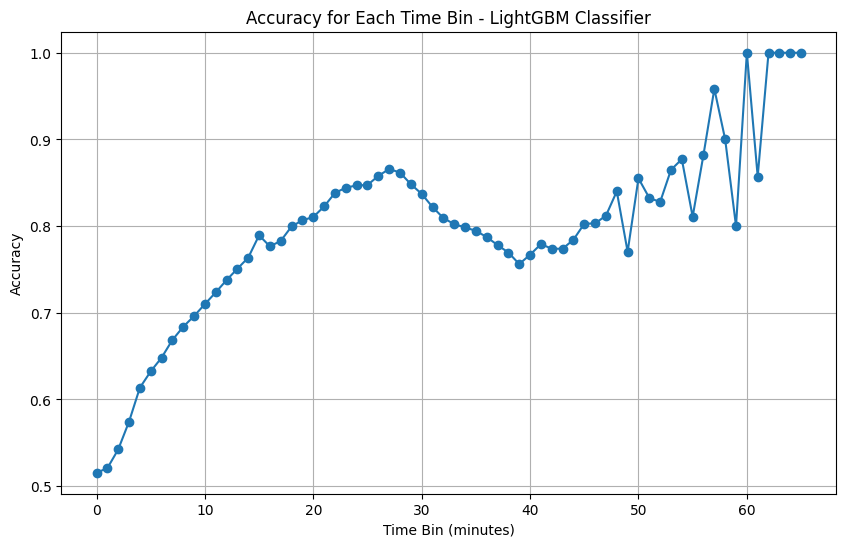

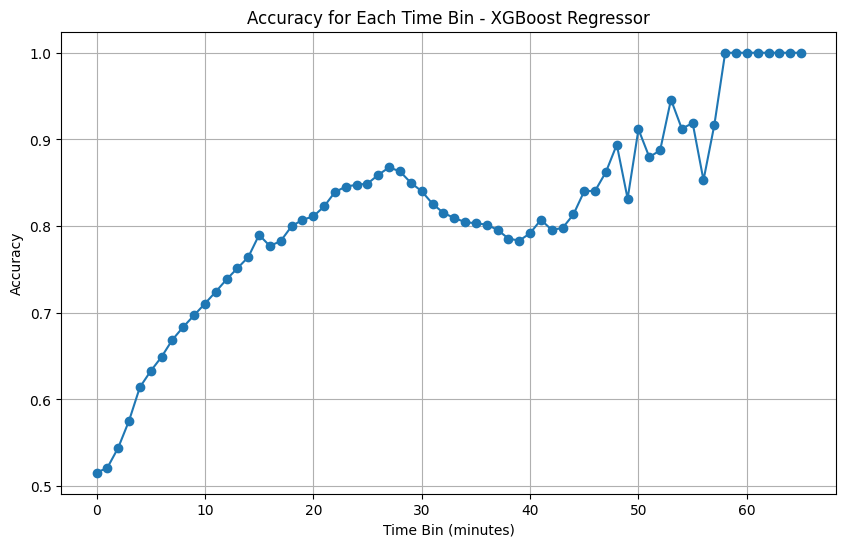

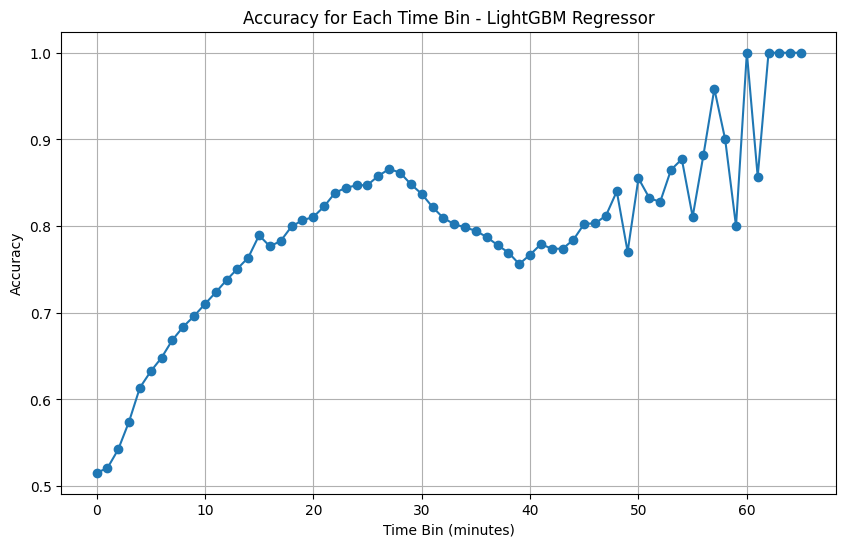

In [23]:
df["time_bin"] = (df["timestamp"] // 60000) * 60000


def predict_classifier(model, X_test, y_test):
    pred = model.predict(X_test)
    return accuracy_score(y_test, pred)

def predict_regressor(model, X_test, y_test):
    pred = model.predict(X_test)
    return accuracy_score(y_test, np.round(np.clip(pred, 0, 1)))

def plot_accuracy_over_time(model, label, df, prediction):
    minutes = []
    accuracies = []
    for time_bin, df_bin in df.groupby("time_bin"):
        minutes.append(time_bin // 60000)
        X_test_bin = df_bin.drop(columns=["winner", "time_bin"])
        y_test_bin = df_bin["winner"]
        if "XGBoost" in label:
            X_test_bin = cp.asarray(X_test_bin)
        accuracies.append(prediction(model, X_test_bin, y_test_bin))

    plt.figure(figsize=(10, 6))
    plt.plot(minutes, accuracies, marker='o', linestyle='-')
    plt.title(f'Accuracy for Each Time Bin - {label}')
    plt.xlabel('Time Bin (minutes)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

plot_accuracy_over_time(xgb_model_classifier, 'XGBoost Classifier', df, predict_classifier)
plot_accuracy_over_time(lgb_model_classifier, 'LightGBM Classifier', df, predict_classifier)

plot_accuracy_over_time(xgb_model_classifier, 'XGBoost Regressor', df, predict_classifier)
plot_accuracy_over_time(lgb_model_classifier, 'LightGBM Regressor', df, predict_classifier)